# PCA

I wanted this notebook to make PCA feel practical instead of purely geometric. I kept one section for interpretation and one section for feature extraction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

## PCA on breast cancer features

I started with the breast cancer dataset because the raw feature scales are very different. Scaling first makes the principal directions much easier to interpret.

In [2]:
cancer = load_breast_cancer(as_frame=True)
X_cancer = cancer.data
y_cancer = pd.Series(cancer.target, name='target').map(dict(enumerate(cancer.target_names)))

summary = pd.DataFrame({
    'rows': [X_cancer.shape[0]],
    'features': [X_cancer.shape[1]],
    'malignant': [(y_cancer == 'malignant').sum()],
    'benign': [(y_cancer == 'benign').sum()],
})
display(summary)
X_cancer.describe().T[['mean', 'std']].head()

,rows,features,malignant,benign
0,569,30,212,357


,mean,std
mean radius,14.127292,3.524049
mean texture,19.289649,4.301036
mean perimeter,91.969033,24.298981
mean area,654.889104,351.914129
mean smoothness,0.096360,0.014064


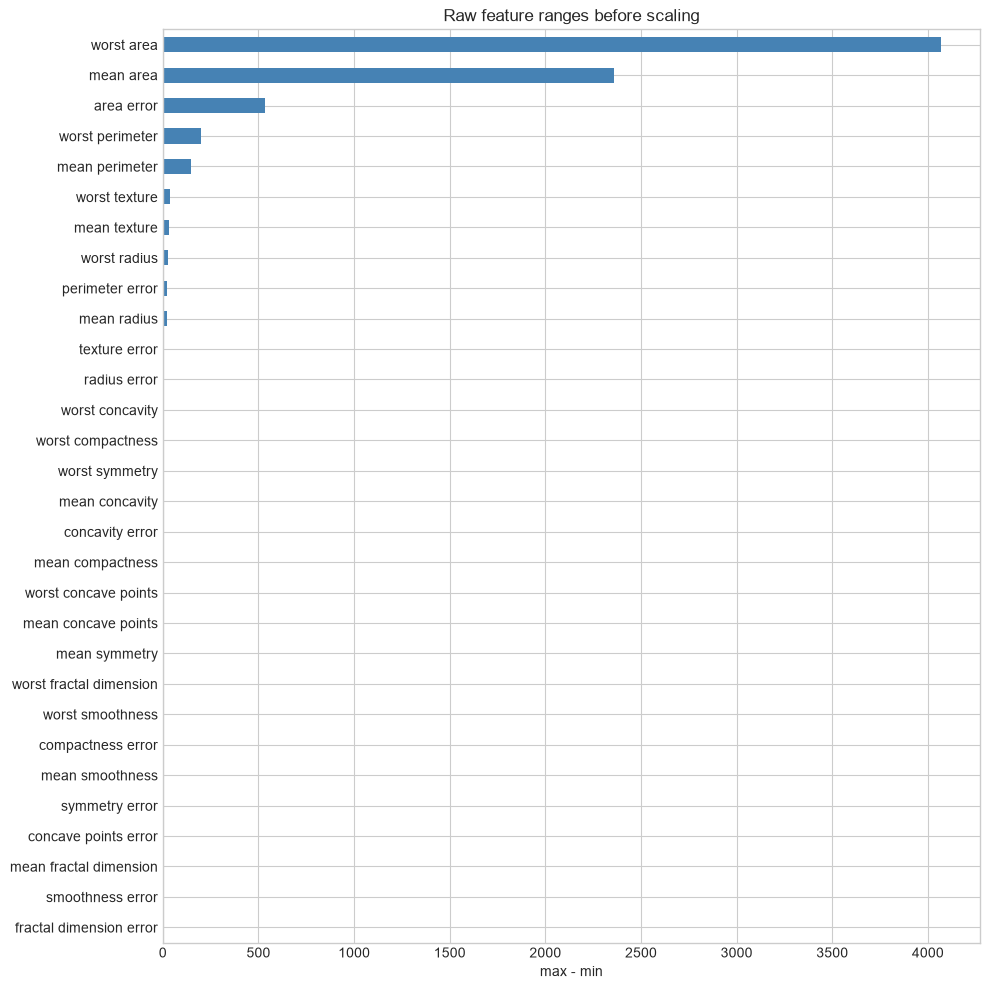

In [3]:
feature_spread = X_cancer.max() - X_cancer.min()
feature_spread.sort_values().plot(kind='barh', figsize=(10, 10), color='steelblue')
plt.title('Raw feature ranges before scaling')
plt.xlabel('max - min')
plt.tight_layout()
plt.show()

,component,explained_variance_ratio,cumulative_ratio
0,PC1,0.443,0.443
1,PC2,0.190,0.632


,PC1,PC2
target,,
benign,-2.206,0.346
malignant,3.715,-0.583


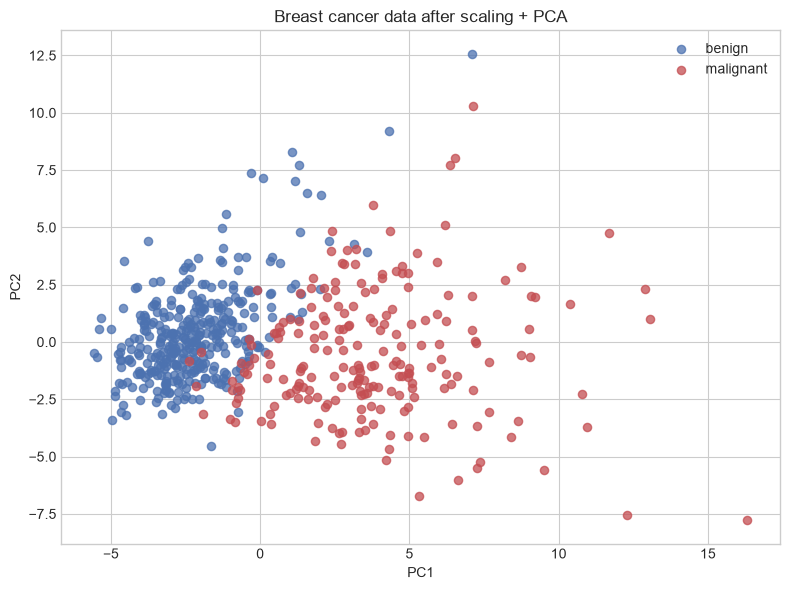

In [4]:
cancer_scaler = StandardScaler()
X_cancer_scaled = cancer_scaler.fit_transform(X_cancer)
pca_2d = PCA(n_components=2, random_state=42)
X_cancer_pca = pca_2d.fit_transform(X_cancer_scaled)

explained = pd.DataFrame({
    'component': ['PC1', 'PC2'],
    'explained_variance_ratio': pca_2d.explained_variance_ratio_,
})
explained['cumulative_ratio'] = explained['explained_variance_ratio'].cumsum()
display(explained.round(3))

class_means = pd.DataFrame(X_cancer_pca, columns=['PC1', 'PC2']).assign(target=y_cancer).groupby('target')[['PC1', 'PC2']].mean()
display(class_means.round(3))

colors = {'malignant': '#c44e52', 'benign': '#4c72b0'}
fig, ax = plt.subplots(figsize=(8, 6))
for label, group in pd.DataFrame(X_cancer_pca, columns=['PC1', 'PC2']).assign(target=y_cancer).groupby('target'):
    ax.scatter(group['PC1'], group['PC2'], label=label, alpha=0.75, s=35, color=colors[label])
ax.set_title('Breast cancer data after scaling + PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

The first two components explain about **63.2%** of the variance after scaling. In this run, the malignant samples had a mean PC1 value near **3.71**, while the benign samples were near **-2.21**, so PC1 already carries a lot of class structure.

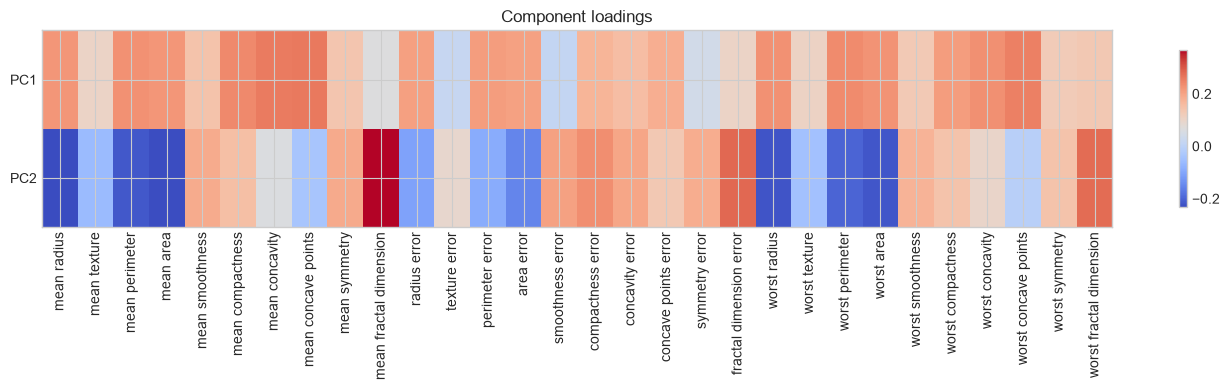

,PC1_abs_loading,PC2_abs_loading
mean concave points,0.260854,NaN
mean concavity,0.258400,NaN
worst concave points,0.250886,NaN
mean compactness,0.239285,NaN
worst perimeter,0.236640,NaN
mean fractal dimension,NaN,0.366575
fractal dimension error,NaN,0.280092
worst fractal dimension,NaN,0.275339
mean radius,NaN,0.233857
compactness error,NaN,0.232716


In [5]:
loadings = pd.DataFrame(pca_2d.components_, columns=X_cancer.columns, index=['PC1', 'PC2'])
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(loadings, cmap='coolwarm', aspect='auto')
ax.set_yticks([0, 1], labels=['PC1', 'PC2'])
ax.set_xticks(range(X_cancer.shape[1]))
ax.set_xticklabels(X_cancer.columns, rotation=90)
ax.set_title('Component loadings')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

top_loadings = pd.concat([
    loadings.loc['PC1'].abs().sort_values(ascending=False).head(5).rename('PC1_abs_loading'),
    loadings.loc['PC2'].abs().sort_values(ascending=False).head(5).rename('PC2_abs_loading')
], axis=1)
top_loadings

## PCA for feature extraction

For a predictive example, I switched to the digits dataset so everything stays local and reproducible. I also kept scaling and PCA inside the pipeline so cross-validation never sees test-fold information.

In [6]:
digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target,
    test_size=0.25,
    stratify=digits.target,
    random_state=42
)

baseline_model = Pipeline([
    ('scale', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=5000, random_state=42))
])
baseline_model.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline_model.predict(X_test))
pd.DataFrame({'model': ['Logistic regression baseline'], 'test_accuracy': [baseline_accuracy]}).round(3)

,model,test_accuracy
0,Logistic regression baseline,0.978


In [7]:
search = GridSearchCV(
    Pipeline([
        ('scale', StandardScaler()),
        ('pca', PCA(random_state=42)),
        ('logreg', LogisticRegression(max_iter=5000, random_state=42))
    ]),
    param_grid={
        'pca__n_components': [10, 20, 30, 40, 50],
        'logreg__C': [0.1, 1.0, 10.0]
    },
    cv=5,
    n_jobs=1
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
best_pca = best_model.named_steps['pca']
pca_accuracy = accuracy_score(y_test, best_model.predict(X_test))

results = pd.DataFrame(search.cv_results_)[['param_pca__n_components', 'param_logreg__C', 'mean_test_score', 'rank_test_score']]
results = results.sort_values(['rank_test_score', 'param_pca__n_components']).reset_index(drop=True)
display(results.head(10).rename(columns={
    'param_pca__n_components': 'n_components',
    'param_logreg__C': 'C',
    'mean_test_score': 'cv_accuracy',
    'rank_test_score': 'rank'
}).round(3))

pd.DataFrame({
    'model': ['Baseline logistic regression', 'PCA + logistic regression'],
    'test_accuracy': [baseline_accuracy, pca_accuracy],
    'selected_components': [np.nan, best_pca.n_components_],
    'variance_kept': [np.nan, best_pca.explained_variance_ratio_.sum()]
}).round(3)

,n_components,C,cv_accuracy,rank
0,50,1.0,0.968,1
1,50,10.0,0.967,2
2,40,10.0,0.967,3
3,40,1.0,0.966,4
4,50,0.1,0.963,5
5,30,1.0,0.962,6
6,40,0.1,0.961,7
7,30,10.0,0.955,8
8,30,0.1,0.953,9
9,20,1.0,0.950,10


,model,test_accuracy,selected_components,variance_kept
0,Baseline logistic regression,0.978,NaN,NaN
1,PCA + logistic regression,0.980,50.0,0.984


In this run, the plain logistic regression baseline reached **97.8%** test accuracy. After tuning PCA inside the pipeline, the best model kept **50** components, preserved about **98.4%** of the training variance, and nudged test accuracy to **98.0%**.

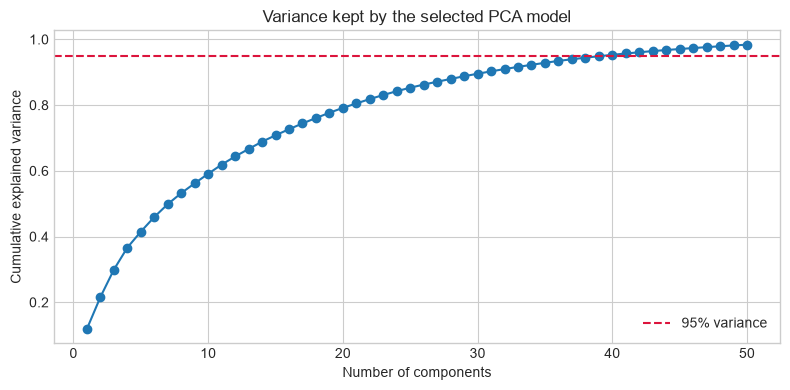

In [8]:
train_scaler = best_model.named_steps['scale']
X_train_scaled = train_scaler.transform(X_train)
cumulative_variance = np.cumsum(best_pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
ax.axhline(0.95, color='crimson', linestyle='--', label='95% variance')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('Variance kept by the selected PCA model')
ax.legend()
plt.tight_layout()
plt.show()

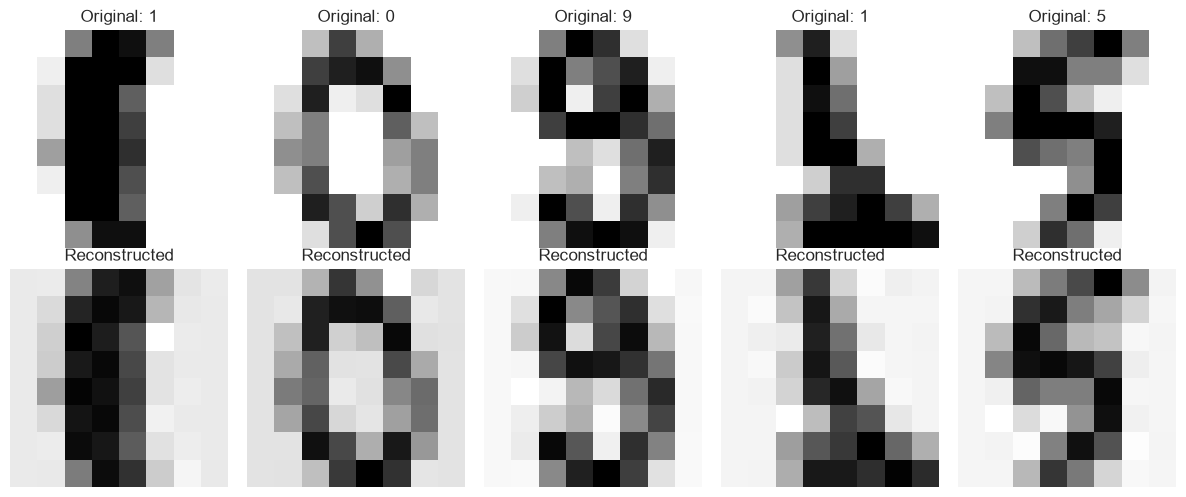

In [9]:
# Reconstructing test digits helps me see what information PCA keeps and what it smooths away.
X_test_scaled = train_scaler.transform(X_test[:5])
X_test_pca = best_pca.transform(X_test_scaled)
X_test_reconstructed = train_scaler.inverse_transform(best_pca.inverse_transform(X_test_pca))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap='gray_r')
    axes[0, i].set_title(f'Original: {y_test[i]}')
    axes[1, i].imshow(X_test_reconstructed[i].reshape(8, 8), cmap='gray_r')
    axes[1, i].set_title('Reconstructed')
    axes[0, i].axis('off')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

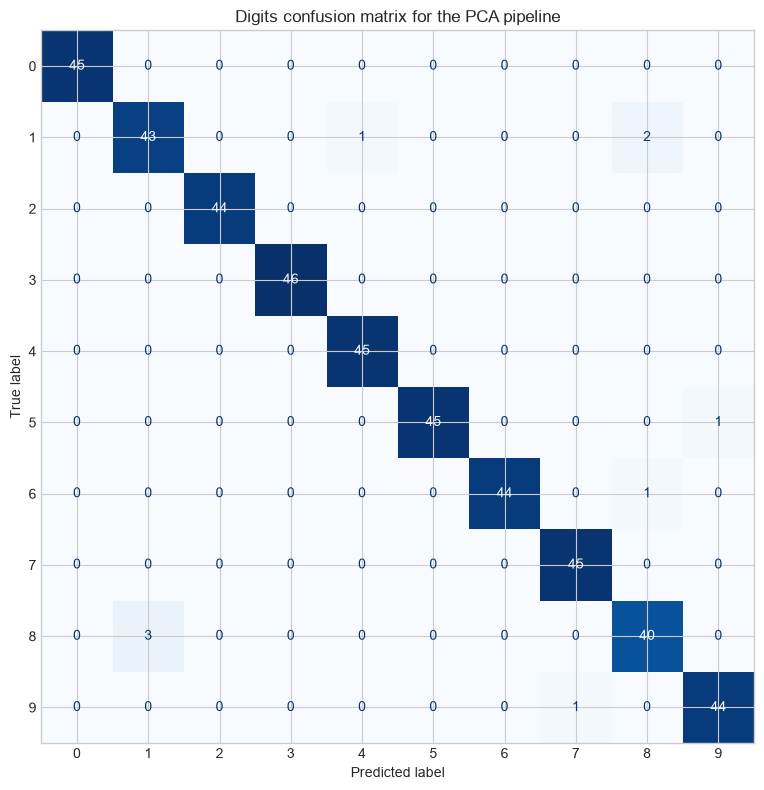

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, best_model.predict(X_test), cmap='Blues', colorbar=False, ax=ax)
ax.set_title('Digits confusion matrix for the PCA pipeline')
plt.tight_layout()
plt.show()

## What I learned

After scaling, PCA gave me a compact view of the cancer dataset and showed that PC1 carries most of the separation. On digits, PCA was not just a plotting trick: with the right number of components, I could compress the feature space a lot and still keep accuracy essentially unchanged.